# Dual-Track Retrieval Experimentation Notebook

This notebook implements the updated experimentation plan for dual-track synthetic corpora.

It evaluates three query language subsets against three search-corpus conditions:

1. French queries
2. Lingala queries
3. Swahili queries

Search conditions:

1. Track A: French-Swahili based with Lingala sprinkle
2. Track B: French-Lingala based with Swahili sprinkle
3. Track A+B shuffled mix

## Cell Order

1. Setup and paths
2. Load and prepare dual-track corpora
3. Build query pools and candidate pools
4. Run retrieval baseline over full 3x3 matrix
5. Save CSV tables
6. Plot matrix metrics (display + save)
7. Plot query counts and switch diagnostics (display + save)

All plot cells display figures inline and also save PNG files.

In [18]:
# Cell 1: Setup imports, reproducibility, and output paths.
# This cell initializes dependencies and ensures output folders exist for CSV/PNG artifacts.

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Sequence
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)

ROOT = Path.cwd()
DUAL_TEXT_DIR = ROOT / "synthesis_outputs" / "text" / "dual_track"

TRACK_PATHS = {
    "track_a": DUAL_TEXT_DIR / "cs_text_track_a_fra_swa_linspr.jsonl",
    "track_b": DUAL_TEXT_DIR / "cs_text_track_b_fra_lin_swaspr.jsonl",
    "track_ab": DUAL_TEXT_DIR / "cs_text_track_ab_shuffled.jsonl",
}

OUT_DIR = ROOT / "experiment_outputs" / "dual_track"
CSV_DIR = OUT_DIR / "csv"
PLOT_DIR = OUT_DIR / "plots"
CSV_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)
print("Dual-track text dir:", DUAL_TEXT_DIR)
print("CSV output dir:", CSV_DIR)
print("Plot output dir:", PLOT_DIR)

Root: c:\cmu\course-work\spring-1\applications-ai-africa\group-work
Dual-track text dir: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\synthesis_outputs\text\dual_track
CSV output dir: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\experiment_outputs\dual_track\csv
Plot output dir: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\experiment_outputs\dual_track\plots


In [19]:
# Cell 2: Load dual-track corpora and prepare analysis fields.
# This cell reads JSONL files, assigns deterministic splits, and derives query-language/switch features.

import hashlib
import re

def load_jsonl(path: Path) -> List[dict]:
    rows: List[dict] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def parse_numeric_id(item_id: str) -> str:
    m = re.search(r"(\d+)$", str(item_id))
    return m.group(1) if m else str(item_id)

def stable_split_from_id(item_id: str) -> str:
    # Split by numeric id so paired Track A/B examples stay in the same split.
    split_key = parse_numeric_id(item_id)
    digest = hashlib.md5(split_key.encode("utf-8")).hexdigest()
    score = int(digest[:8], 16) % 100
    if score < 80:
        return "train"
    if score < 90:
        return "dev"
    return "test"

def language_counts(tags: Sequence[str]) -> dict:
    counts = {"fra": 0, "swa": 0, "lin": 0}
    for t in tags:
        if t in counts:
            counts[t] += 1
    return counts

def dominant_query_language(tags: Sequence[str]) -> str:
    counts = language_counts(tags)
    if sum(counts.values()) == 0:
        return "unknown"
    return max(counts, key=counts.get)

def dominant_non_french_language(tags: Sequence[str]) -> str:
    counts = language_counts(tags)
    if counts["lin"] == 0 and counts["swa"] == 0:
        return "unknown"
    return "lin" if counts["lin"] >= counts["swa"] else "swa"

def switch_ratio(tags: Sequence[str], matrix_lang: str) -> float:
    seq = [t for t in tags if t in {"fra", "swa", "lin"}]
    if not seq:
        return 0.0
    m = matrix_lang if matrix_lang in {"fra", "swa", "lin"} else dominant_query_language(seq)
    switched = sum(1 for t in seq if t != m)
    return switched / len(seq)

def switch_band(v: float) -> str:
    if v < 0.2:
        return "low"
    if v < 0.5:
        return "medium"
    return "high"

def infer_source_track(item_id: str) -> str:
    s = str(item_id)
    if s.startswith("track_a_"):
        return "track_a"
    if s.startswith("track_b_"):
        return "track_b"
    return "unknown"

def token_set_from_row(tokens: Sequence[str], text: str) -> set:
    if isinstance(tokens, list) and tokens:
        return {str(tok).lower() for tok in tokens if str(tok).strip()}
    return {part.lower() for part in str(text).split() if part.strip()}

corpora: Dict[str, pd.DataFrame] = {}
for corpus_name, path in TRACK_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing expected corpus file: {path}")
    rows = load_jsonl(path)
    df = pd.DataFrame(rows)
    df["corpus"] = corpus_name
    df["id_num"] = df["id"].apply(parse_numeric_id)
    df["source_track"] = df["id"].apply(infer_source_track)
    df["split"] = df["id"].apply(stable_split_from_id)
    df["query_lang"] = df["lang_tags"].apply(dominant_query_language)
    df["query_lang_nonfra"] = df["lang_tags"].apply(dominant_non_french_language)
    df["switch_ratio"] = df.apply(lambda r: switch_ratio(r["lang_tags"], r.get("matrix_lang", "")), axis=1)
    df["switch_band"] = df["switch_ratio"].apply(switch_band)
    df["token_set"] = df.apply(lambda r: token_set_from_row(r.get("tokens", []), r.get("text", "")), axis=1)
    corpora[corpus_name] = df

corpus_summary = pd.concat([
    df.groupby(["split", "query_lang"]).size().rename("count").reset_index().assign(corpus=name)
    for name, df in corpora.items()
], ignore_index=True)

print("Loaded corpora:")
for name, df in corpora.items():
    print(f"- {name}: {len(df):,} rows")

display(corpus_summary.sort_values(["corpus", "split", "query_lang"]))

Loaded corpora:
- track_a: 4,000 rows
- track_b: 4,000 rows
- track_ab: 8,000 rows


,split,query_lang,count,corpus
0,dev,fra,357,track_a
1,dev,swa,21,track_a
2,test,fra,367,track_a
3,test,swa,23,track_a
4,train,fra,3067,track_a
5,train,swa,165,track_a
12,dev,fra,712,track_ab
13,dev,lin,23,track_ab
14,dev,swa,21,track_ab
15,test,fra,740,track_ab


In [20]:
# Cell 3: Build retrieval utilities and run the 3x3 evaluation matrix.
# This cell enforces a non-empty 3x3 with distinct FRA/LIN/SWA query subsets and robust gold mapping.

def reciprocal_rank(ranked_ids: Sequence[str], gold_id: str) -> float:
    for i, cid in enumerate(ranked_ids, start=1):
        if cid == gold_id:
            return 1.0 / i
    return 0.0

def recall_at_1(ranked_ids: Sequence[str], gold_id: str) -> float:
    return float(len(ranked_ids) > 0 and ranked_ids[0] == gold_id)

def ndcg_at_5(ranked_ids: Sequence[str], gold_id: str) -> float:
    for i, cid in enumerate(ranked_ids[:5], start=1):
        if cid == gold_id:
            return 1.0 / math.log2(i + 1)
    return 0.0

def csrs_from_df(frame: pd.DataFrame) -> float:
    if frame.empty:
        return np.nan
    by_band = frame.groupby("switch_band")["rr"].mean().to_dict()
    low = by_band.get("low", np.nan)
    high = by_band.get("high", np.nan)
    if pd.isna(low) or pd.isna(high) or low == 0:
        return np.nan
    return float(high / low)

def build_pair_map(track_a_df: pd.DataFrame, track_b_df: pd.DataFrame) -> Dict[str, str]:
    # Pair A and B by numeric id so each query's preferred gold is a non-self counterpart.
    a_map = track_a_df.set_index("id_num")["id"].to_dict()
    b_map = track_b_df.set_index("id_num")["id"].to_dict()
    shared = set(a_map.keys()) & set(b_map.keys())
    pair_map: Dict[str, str] = {}
    for key in shared:
        a_id = a_map[key]
        b_id = b_map[key]
        pair_map[a_id] = b_id
        pair_map[b_id] = a_id
    return pair_map

def make_candidate_pool(
    ranked_all: Sequence[str],
    query_id: str,
    gold_id: str,
    all_ids: Sequence[str],
    hard_k: int = 9,
    rand_k: int = 40,
    fixed_size: int = 50,
    ) -> List[str]:
    negatives = [cid for cid in ranked_all if cid not in {query_id, gold_id}]
    hard = negatives[:hard_k]
    remaining = [cid for cid in all_ids if cid not in {query_id, gold_id, *hard}]
    sample_size = min(rand_k, len(remaining))
    rand = rng.choice(np.array(remaining, dtype=object), size=sample_size, replace=False).tolist() if sample_size else []
    pool = [gold_id, *hard, *rand]

    if len(pool) < fixed_size:
        used = set(pool) | {query_id}
        filler = [cid for cid in all_ids if cid not in used]
        need = min(fixed_size - len(pool), len(filler))
        if need > 0:
            pool.extend(filler[:need])
    return pool

def choose_gold_id(
    row,
    search_df: pd.DataFrame,
    search_id_set: set,
    pair_map: Dict[str, str],
    ) -> str | None:
    paired = pair_map.get(row.id)
    if paired in search_id_set and paired != row.id:
        return paired

    same_num = search_df[search_df["id_num"] == row.id_num]["id"].tolist()
    same_num = [cid for cid in same_num if cid != row.id]
    if same_num:
        return same_num[0]

    q_tokens = row.token_set if isinstance(row.token_set, set) else set()
    if not q_tokens:
        q_tokens = {part.lower() for part in str(row.text).split() if part.strip()}

    best_id = None
    best_score = -1
    for cand in search_df.itertuples(index=False):
        if cand.id == row.id:
            continue
        cand_tokens = cand.token_set if isinstance(cand.token_set, set) else set()
        overlap = len(q_tokens & cand_tokens)
        if overlap > best_score:
            best_score = overlap
            best_id = cand.id
        elif overlap == best_score and best_id is not None and str(cand.id) < str(best_id):
            best_id = cand.id

    return best_id

def query_subset_for_lang(frame: pd.DataFrame, q_lang: str) -> pd.DataFrame:
    # FRA uses dominant language; LIN/SWA use dominant non-French language for distinct subsets.
    if q_lang == "fra":
        return frame[frame["query_lang"] == "fra"].copy()
    if q_lang == "lin":
        return frame[frame["query_lang_nonfra"] == "lin"].copy()
    if q_lang == "swa":
        return frame[frame["query_lang_nonfra"] == "swa"].copy()
    return frame.iloc[0:0].copy()

query_languages = ["fra", "lin", "swa"]
search_conditions = ["track_a", "track_b", "track_ab"]

track_a_test = corpora["track_a"].query("split == 'test'").copy()
track_b_test = corpora["track_b"].query("split == 'test'").copy()
track_ab_test = corpora["track_ab"].query("split == 'test'").copy()
pair_map = build_pair_map(track_a_test, track_b_test)

query_frame = track_ab_test.copy()

search_bundles = {}
for search_name in search_conditions:
    search_df = corpora[search_name].query("split == 'test'").copy()
    search_ids = search_df["id"].tolist()
    search_id_to_idx = {cid: idx for idx, cid in enumerate(search_ids)}
    vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1)
    search_matrix = vectorizer.fit_transform(search_df["text"].tolist())
    search_bundles[search_name] = {
        "df": search_df,
        "ids": search_ids,
        "id_set": set(search_ids),
        "idx_map": search_id_to_idx,
        "vectorizer": vectorizer,
        "matrix": search_matrix,
    }

all_query_level_rows: List[dict] = []
matrix_rows: List[dict] = []

for search_name in search_conditions:
    bundle = search_bundles[search_name]
    search_df = bundle["df"]
    search_ids = bundle["ids"]
    search_id_set = bundle["id_set"]
    idx_map = bundle["idx_map"]

    for q_lang in query_languages:
        q_subset = query_subset_for_lang(query_frame, q_lang)

        cell_rows: List[dict] = []
        for row in q_subset.itertuples(index=False):
            gold_id = choose_gold_id(
                row=row,
                search_df=search_df,
                search_id_set=search_id_set,
                pair_map=pair_map,
            )
            if gold_id is None or gold_id not in search_id_set:
                continue

            q_vec = bundle["vectorizer"].transform([row.text])
            scores = cosine_similarity(q_vec, bundle["matrix"]).ravel()
            ranked_all = [search_ids[i] for i in np.argsort(-scores)]

            pool = make_candidate_pool(
                ranked_all=ranked_all,
                query_id=row.id,
                gold_id=gold_id,
                all_ids=search_ids,
                hard_k=9,
                rand_k=40,
                fixed_size=50,
            )

            pool_scores = {cid: float(scores[idx_map[cid]]) for cid in pool}
            ranked = [cid for cid, _ in sorted(pool_scores.items(), key=lambda kv: kv[1], reverse=True)]

            rec = {
                "query_id": row.id,
                "gold_id": gold_id,
                "query_language": q_lang,
                "search_corpus": search_name,
                "switch_band": row.switch_band,
                "rr": reciprocal_rank(ranked, gold_id),
                "r1": recall_at_1(ranked, gold_id),
                "ndcg5": ndcg_at_5(ranked, gold_id),
                "candidate_pool_size": len(pool),
            }
            cell_rows.append(rec)
            all_query_level_rows.append(rec)

        cell_df = pd.DataFrame(cell_rows)
        matrix_rows.append({
            "query_language": q_lang,
            "search_corpus": search_name,
            "n_queries": len(cell_df),
            "MRR": float(cell_df["rr"].mean()) if not cell_df.empty else np.nan,
            "Recall@1": float(cell_df["r1"].mean()) if not cell_df.empty else np.nan,
            "nDCG@5": float(cell_df["ndcg5"].mean()) if not cell_df.empty else np.nan,
            "CSRS": csrs_from_df(cell_df),
        })

results_per_query_df = pd.DataFrame(all_query_level_rows)
matrix_metrics_df = pd.DataFrame(matrix_rows).sort_values(["query_language", "search_corpus"]).reset_index(drop=True)

if (matrix_metrics_df["n_queries"] <= 0).any():
    raise ValueError("Non-empty 3x3 enforcement failed: at least one matrix cell has zero queries.")

print("3x3 matrix metrics:")
display(matrix_metrics_df)

3x3 matrix metrics:


,query_language,search_corpus,n_queries,MRR,Recall@1,nDCG@5,CSRS
0,fra,track_a,740,0.560926,0.467568,0.551251,NaN
1,fra,track_ab,740,0.779965,0.698649,0.792463,NaN
2,fra,track_b,740,0.550527,0.466216,0.536664,NaN
3,lin,track_a,395,0.853946,0.807595,0.859896,NaN
4,lin,track_ab,395,0.749944,0.665823,0.762805,NaN
5,lin,track_b,395,0.248886,0.118987,0.219175,NaN
6,swa,track_a,385,0.258770,0.116883,0.232541,NaN
7,swa,track_ab,385,0.791899,0.711688,0.804674,NaN
8,swa,track_b,385,0.864997,0.823377,0.868728,NaN


In [21]:
# Cell 4: Save all experiment tables to CSV.
# This cell writes reproducible tabular artifacts for downstream reporting.

matrix_metrics_df.to_csv(CSV_DIR / "dual_matrix_metrics.csv", index=False)
results_per_query_df.to_csv(CSV_DIR / "dual_results_per_query.csv", index=False)
corpus_summary.to_csv(CSV_DIR / "dual_corpus_summary.csv", index=False)

if not results_per_query_df.empty:
    by_band = (
        results_per_query_df.groupby(["query_language", "search_corpus", "switch_band"])[["rr", "r1", "ndcg5"]]
        .mean()
        .reset_index()
    )
else:
    by_band = pd.DataFrame(columns=["query_language", "search_corpus", "switch_band", "rr", "r1", "ndcg5"] )

by_band.to_csv(CSV_DIR / "dual_metrics_by_switch_band.csv", index=False)

print("Saved CSV artifacts to:", CSV_DIR)
display(pd.DataFrame({"csv_files": sorted([p.name for p in CSV_DIR.glob("*.csv")])}))

Saved CSV artifacts to: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\experiment_outputs\dual_track\csv


,csv_files
0,dual_corpus_summary.csv
1,dual_matrix_metrics.csv
2,dual_metrics_by_switch_band.csv
3,dual_results_per_query.csv


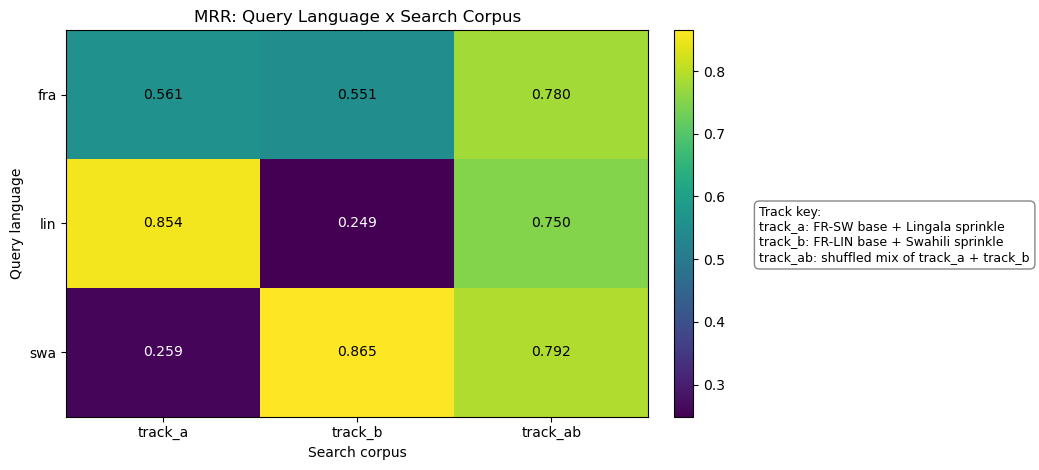

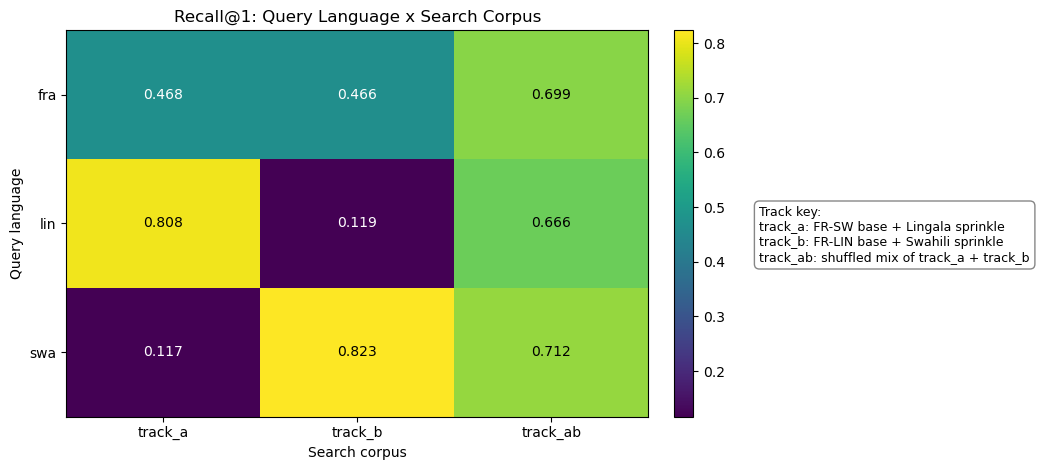

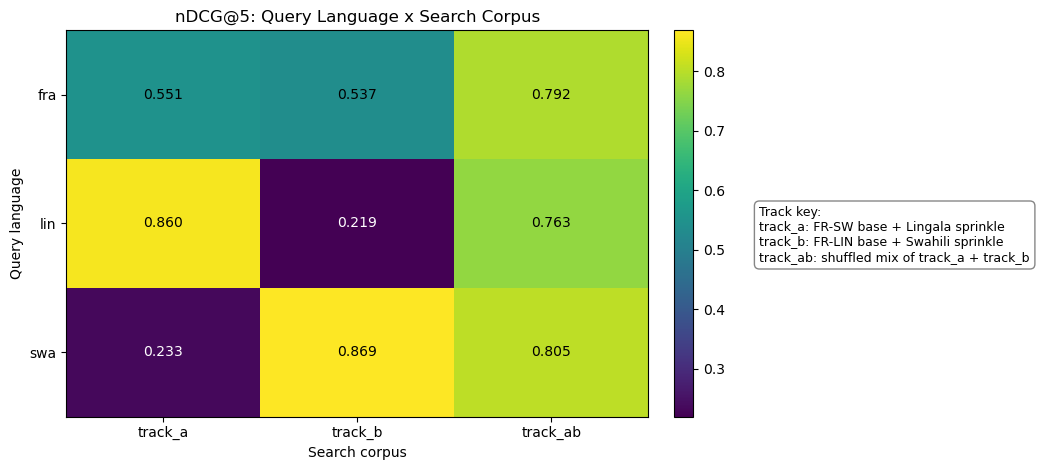

Saved heatmaps to: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\experiment_outputs\dual_track\plots


In [24]:
# Cell 5: Plot the 3x3 metric heatmaps (display + save).
# This cell visualizes MRR, Recall@1, and nDCG@5 across query language and search corpus conditions.

TRACK_KEY_TEXT = (
    "Track key:\n"
    "track_a: FR-SW base + Lingala sprinkle\n"
    "track_b: FR-LIN base + Swahili sprinkle\n"
    "track_ab: shuffled mix of track_a + track_b"
)

def metric_heatmap(metric_col: str, title: str, filename: str):
    piv = matrix_metrics_df.pivot(index="query_language", columns="search_corpus", values=metric_col)
    order_q = [q for q in ["fra", "lin", "swa"] if q in piv.index]
    order_s = [s for s in ["track_a", "track_b", "track_ab"] if s in piv.columns]
    piv = piv.reindex(index=order_q, columns=order_s)

    fig, ax = plt.subplots(figsize=(9.8, 4.8))
    im = ax.imshow(piv.values, aspect="auto")
    ax.set_xticks(range(len(order_s)))
    ax.set_xticklabels(order_s)
    ax.set_yticks(range(len(order_q)))
    ax.set_yticklabels(order_q)
    ax.set_title(title)
    ax.set_xlabel("Search corpus")
    ax.set_ylabel("Query language")

    for i in range(len(order_q)):
        for j in range(len(order_s)):
            val = piv.iloc[i, j]
            txt = "nan" if pd.isna(val) else f"{val:.3f}"
            ax.text(j, i, txt, ha="center", va="center", color="white" if not pd.isna(val) and val < 0.5 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.subplots_adjust(right=0.76)
    fig.text(
        0.78,
        0.50,
        TRACK_KEY_TEXT,
        va="center",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "gray", "alpha": 0.95},
    )
    fig.tight_layout(rect=[0.0, 0.0, 0.76, 1.0])
    fig.savefig(PLOT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

metric_heatmap("MRR", "MRR: Query Language x Search Corpus", "dual_mrr_heatmap.png")
metric_heatmap("Recall@1", "Recall@1: Query Language x Search Corpus", "dual_recall1_heatmap.png")
metric_heatmap("nDCG@5", "nDCG@5: Query Language x Search Corpus", "dual_ndcg5_heatmap.png")

print("Saved heatmaps to:", PLOT_DIR)

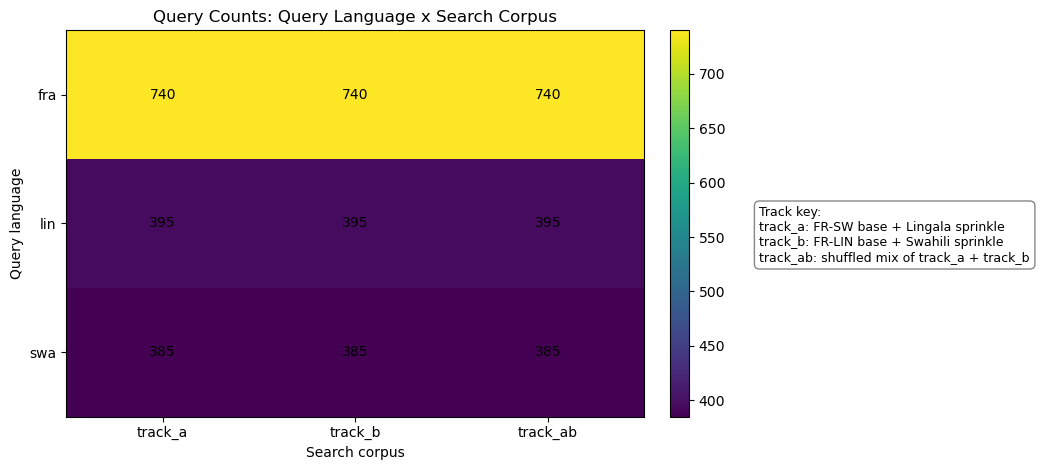

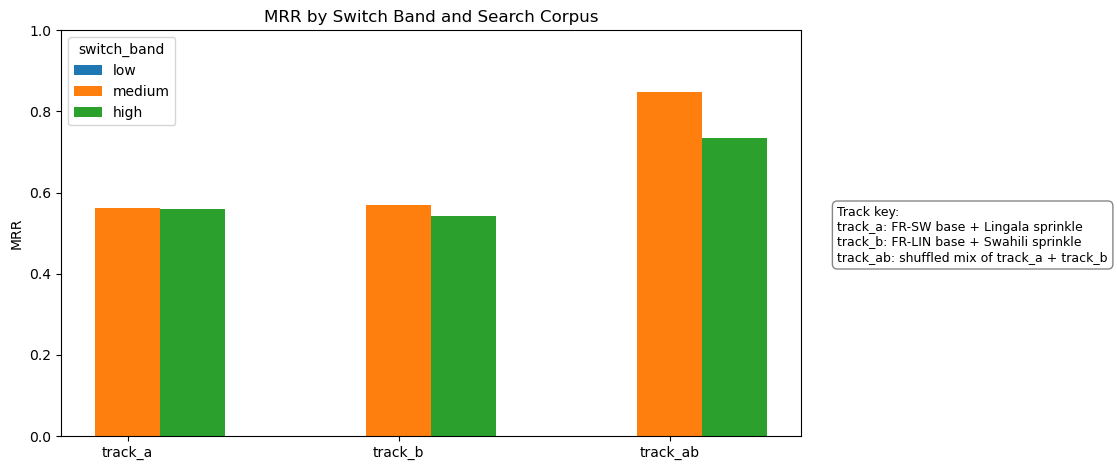

Saved diagnostic plots to: c:\cmu\course-work\spring-1\applications-ai-africa\group-work\experiment_outputs\dual_track\plots


,plot_files
0,dual_mrr_by_switch_band.png
1,dual_mrr_heatmap.png
2,dual_ndcg5_heatmap.png
3,dual_query_count_heatmap.png
4,dual_recall1_heatmap.png


In [25]:
# Cell 6: Plot query counts and switch-band diagnostics (display + save).
# This cell adds diagnostic plots for query coverage and switch-band behavior.

TRACK_KEY_TEXT = (
    "Track key:\n"
    "track_a: FR-SW base + Lingala sprinkle\n"
    "track_b: FR-LIN base + Swahili sprinkle\n"
    "track_ab: shuffled mix of track_a + track_b"
)

count_piv = matrix_metrics_df.pivot(index="query_language", columns="search_corpus", values="n_queries").fillna(0)
order_q = [q for q in ["fra", "lin", "swa"] if q in count_piv.index]
order_s = [s for s in ["track_a", "track_b", "track_ab"] if s in count_piv.columns]
count_piv = count_piv.reindex(index=order_q, columns=order_s)

fig, ax = plt.subplots(figsize=(9.8, 4.8))
im = ax.imshow(count_piv.values, aspect="auto")
ax.set_xticks(range(len(order_s)))
ax.set_xticklabels(order_s)
ax.set_yticks(range(len(order_q)))
ax.set_yticklabels(order_q)
ax.set_title("Query Counts: Query Language x Search Corpus")
ax.set_xlabel("Search corpus")
ax.set_ylabel("Query language")
for i in range(len(order_q)):
    for j in range(len(order_s)):
        ax.text(j, i, str(int(count_piv.iloc[i, j])), ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.subplots_adjust(right=0.76)
fig.text(
    0.78,
    0.50,
    TRACK_KEY_TEXT,
    va="center",
    ha="left",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "gray", "alpha": 0.95},
)
fig.tight_layout(rect=[0.0, 0.0, 0.76, 1.0])
fig.savefig(PLOT_DIR / "dual_query_count_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

if not results_per_query_df.empty:
    band_plot = (
        results_per_query_df.groupby(["search_corpus", "switch_band"])["rr"]
        .mean()
        .reset_index()
    )
    band_order = ["low", "medium", "high"]
    x = np.arange(len(order_s))
    width = 0.24

    fig, ax = plt.subplots(figsize=(10.8, 4.8))
    for idx, band in enumerate(band_order):
        vals = []
        for s in order_s:
            hit = band_plot[(band_plot["search_corpus"] == s) & (band_plot["switch_band"] == band)]
            vals.append(float(hit["rr"].iloc[0]) if not hit.empty else np.nan)
        ax.bar(x + (idx - 1) * width, vals, width=width, label=band)

    ax.set_xticks(x)
    ax.set_xticklabels(order_s)
    ax.set_ylim(0, 1)
    ax.set_ylabel("MRR")
    ax.set_title("MRR by Switch Band and Search Corpus")
    ax.legend(title="switch_band", loc="upper left")
    fig.subplots_adjust(right=0.76)
    fig.text(
        0.78,
        0.50,
        TRACK_KEY_TEXT,
        va="center",
        ha="left",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "gray", "alpha": 0.95},
    )
    fig.tight_layout(rect=[0.0, 0.0, 0.76, 1.0])
    fig.savefig(PLOT_DIR / "dual_mrr_by_switch_band.png", dpi=180, bbox_inches="tight")
    plt.show()

print("Saved diagnostic plots to:", PLOT_DIR)
display(pd.DataFrame({"plot_files": sorted([p.name for p in PLOT_DIR.glob("*.png")])}))